<a href="https://colab.research.google.com/github/michealsujan14-spec/ComputerVisionModel04/blob/main/ComputerVision_model04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#imports
import torch
import torch.nn as nn
from torchvision import transforms , datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


In [ ]:
#datatset train and test

train_dataset = datasets.MNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor()
)

test_dataset = datasets.MNIST(
    root = 'data',
    train = False,
    download = True,
    transform = ToTensor()
)

In [ ]:
train_dataloader = DataLoader(
    dataset =train_dataset,
    batch_size = 32,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size = 32,
    shuffle = False
)

In [ ]:
image , label = train_dataset[0]
image , label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
classes_name = train_dataset.classes
classes_name , len(classes_name)

(['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'],
 10)

In [ ]:
imge , labell = train_dataset[0]
imge.shape

torch.Size([1, 28, 28])

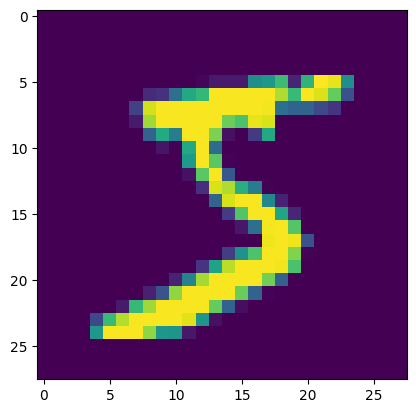

In [ ]:
img , label = train_dataset[0]
plt.imshow(image.squeeze())

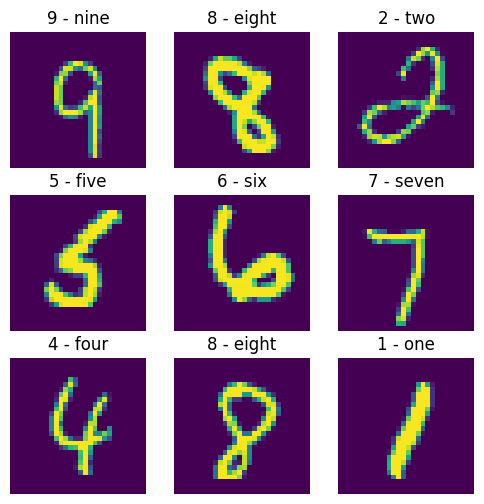

In [ ]:
#make grid of dataset

rows , cols = 3 , 3
plt.figure(figsize=(6,6))
for i in range (1 , rows*cols+1):
  random_idx = torch.randint(1 ,len(train_dataset)+1 , size=[1]).item()
  img , label = train_dataset[random_idx]
  plt.subplot(rows , cols , i)
  plt.title(classes_name[label])
  plt.imshow(img.squeeze())
  plt.axis('off')


In [ ]:
#device agnostic code
device  = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
#Built a model for Conv nn

#CNN Model

class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNeuralNetwork , self).__init__()

        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_channels= 1 , out_channels= 32 , kernel_size= 3 , padding=1 , stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels= 32 , out_channels=64 , kernel_size=3 , stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride= 2)
        )

        self.conv_stack2 = nn.Sequential(
            nn.Conv2d(in_channels= 64 , out_channels= 128 , kernel_size= 3 , padding=1 , stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels= 128 , out_channels=256 , kernel_size=3 , stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride= 2)
        )

        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Linear( 256*7*7 , 128) ,
            nn.ReLU(),
            nn.Linear(128 , 10)
        )

    def forward (self ,x):
        x = self.fully_connected(self.conv_stack2(self.conv_stack(x)))
        return x

In [ ]:
#instance
CNNmodel = ConvolutionalNeuralNetwork().to(device)
CNNmodel ,

(ConvolutionalNeuralNetwork(
   (conv_stack): Sequential(
     (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv_stack2): Sequential(
     (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (fully_connected): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=12544, out_features=128, bias=True)
     (2): ReLU()
     (3): Linear(in_features=128, out_features=10, bias=True)
   )
 ),)

In [ ]:
#loss and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=CNNmodel.parameters() , lr = 0.01)

In [ ]:
#acc funnction
def accuracy_fn(y_true , y_pred):
    correct = torch.eq(y_true , y_pred).sum().item()
    acc = correct / len(y_pred)*100
    return acc

In [ ]:
epochs = 10

for epoch in range(epochs):
    CNNmodel.train()

    train_loss, train_acc = 0, 0
    for batch, (x_train, y_train) in enumerate(train_dataloader):

        x_train = x_train.to(device)
        y_train = y_train.to(device)

        y_logits = CNNmodel(x_train)
        loss = criterion(y_logits, y_train)

        y_pred = torch.argmax(y_logits, dim=1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y_train, y_pred=y_pred)

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    CNNmodel.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():

        for batch, (x_test, y_test) in enumerate(test_dataloader):

            x_test = x_test.to(device)
            y_test = y_test.to(device)

            test_logits = CNNmodel(x_test)
            loss = criterion(test_logits, y_test)

            test_pred = torch.argmax(test_logits, dim=1)

            test_loss += loss.item()
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred)

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    print(
        f"Epoch: {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch: 1/10 | Train Loss: 0.2851 | Train Acc: 92.22% | Test Loss: 0.1512 | Test Acc: 95.40%
Epoch: 2/10 | Train Loss: 0.0990 | Train Acc: 97.02% | Test Loss: 0.0741 | Test Acc: 97.61%
Epoch: 3/10 | Train Loss: 0.0958 | Train Acc: 97.21% | Test Loss: 0.0892 | Test Acc: 97.18%
Epoch: 4/10 | Train Loss: 0.0907 | Train Acc: 97.34% | Test Loss: 0.0880 | Test Acc: 97.38%
Epoch: 5/10 | Train Loss: 0.0867 | Train Acc: 97.47% | Test Loss: 0.0836 | Test Acc: 97.52%
Epoch: 6/10 | Train Loss: 0.0883 | Train Acc: 97.54% | Test Loss: 0.0719 | Test Acc: 97.98%
Epoch: 7/10 | Train Loss: 0.0843 | Train Acc: 97.62% | Test Loss: 0.0908 | Test Acc: 97.20%
Epoch: 8/10 | Train Loss: 0.0844 | Train Acc: 97.59% | Test Loss: 0.0786 | Test Acc: 97.60%
Epoch: 9/10 | Train Loss: 0.0867 | Train Acc: 97.61% | Test Loss: 0.0691 | Test Acc: 98.02%
Epoch: 10/10 | Train Loss: 0.0917 | Train Acc: 97.55% | Test Loss: 0.0754 | Test Acc: 97.90%
